# Course Project Final Notebook (v2 — Extended Methods)

**Name:** William Sandoval
**ASU ID:** 1239514175
**Project Title:** What Drives Enrollment Decisions in Martial Arts Schools?
**Dataset:** Yelp Open Dataset, filtered to martial arts businesses and associated reviews

## Business Question
What factors in Yelp reviews influence a customer's decision to enroll in a martial arts school?

## What changed in v2
This version extends the original analysis with three additional NLP methods drawn from later labs in the course, so the final project demonstrates the full progression of techniques covered:

- **Llama 3.2 LLM-based sentiment** (zero-shot + few-shot prompting, from LA6) — compared against VADER
- **BERTopic** (transformer-embedding topic modeling with `topics_per_class`, from LA5) — compared against LDA
- **GRU with GloVe embeddings** (deep learning classifier, from LA4) — compared against TF-IDF + Linear SVM

A final **Methods Comparison** section summarizes performance across the classical, neural, and LLM-based approaches.

## Runtime expectations
- LDA, VADER, TF-IDF+SVM cells run in seconds.
- BERTopic fitting on ~3,200 reviews takes 5-10 minutes (uses Colab GPU if available).
- GRU training takes 3-5 minutes on Colab GPU.
- **Llama sentiment is the slowest cell** — running on a balanced 200-review sample takes ~10-15 minutes via Ollama. Adjust `LLM_SAMPLE_SIZE` below if needed.

## 1. Business Problem Definition

The martial arts market is competitive, and prospective students or parents often rely on online reviews before deciding which academy to visit. For a martial arts school owner, Yelp reviews can reveal what customers value most, such as instructor quality, class atmosphere, cleanliness, pricing, kids programs, or beginner friendliness.

The business objective is to identify the review themes and sentiment patterns that can support better marketing, retention, and enrollment decisions. The final project rubric emphasizes a clear data-driven business problem, EDA, NLP methodology, results, business insights, and clean code quality.

## 2. Data Sources and Local Filtering Process

The original Yelp files used for this project were:

- `yelp_academic_dataset_business.json`: business categories, ratings, location, and review counts
- `yelp_academic_dataset_review.json`: customer-written review text and review-level metadata

Because the review JSON file is very large, it was filtered locally before being uploaded into Colab. The local filtering process selected reviews connected to the martial arts businesses found in `business_filtered.csv`. This created a smaller project-ready file called `reviews_filtered.csv`.

Expected project files for this notebook:

- `business_filtered.csv`
- `reviews_filtered.csv`

In [1]:
# ============================================================
# Code Cell 1: Import required libraries
# ============================================================
# All imports for the classical pipeline are grouped here.
# Imports specific to the new methods (BERTopic, TensorFlow,
# Ollama) are loaded inside their respective sections to keep
# Colab install steps near the code that uses them.
# ============================================================

import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# VADER lexicon-based sentiment scorer
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    !pip install -q vaderSentiment
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Display options
pd.set_option('display.max_colwidth', 200)
plt.rcParams['figure.figsize'] = (8, 5)
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 3. Load Project Data

This section loads the filtered Yelp review and business files. The goal is to avoid repeatedly changing file paths throughout the notebook. If the files are uploaded to Colab, the notebook uses them directly. If they are saved in Google Drive, update only the two path variables below.

In [2]:
# ============================================================
# Code Cell 2: Load filtered Yelp data
# ============================================================

business_path = "business_filtered.csv"
review_path = "reviews_filtered.csv"

# If using Google Drive, uncomment and update these paths if needed:
# business_path = "/content/drive/MyDrive/business_filtered.csv"
# review_path = "/content/drive/MyDrive/reviews_filtered.csv"

business_df = pd.read_csv(business_path)
reviews_df = pd.read_csv(review_path)

print("Businesses loaded:", business_df.shape)
print("Reviews loaded:", reviews_df.shape)

business_df.head()

Businesses loaded: (265, 14)
Reviews loaded: (3295, 9)


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,tFh0DrDMTom4B3pHpDpRNQ,Platoon Fitness,716 Walnut St,Philadelphia,PA,19106,39.947853,-75.153582,5.0,10,1,"{'BikeParking': 'True', 'ByAppointmentOnly': 'True', 'AcceptsInsurance': 'True', 'WiFi': ""u'free'"", 'BusinessAcceptsCreditCards': 'True', 'WheelchairAccessible': 'True'}","Boot Camps, Weight Loss Centers, Health & Medical, Gyms, Trainers, Fitness & Instruction, Active Life, Martial Arts, Massage Therapy, Nutritionists","{'Monday': '4:0-22:0', 'Tuesday': '4:0-22:0', 'Wednesday': '4:0-22:0', 'Thursday': '4:0-22:0', 'Friday': '4:0-22:0', 'Saturday': '4:0-22:0', 'Sunday': '4:0-22:0'}"
1,qbzS1MqOk6x2aPYzxxEqRg,SBG Idaho,"528 S Americana Blvd, Ste 160",Boise,ID,83702,43.617806,-116.215990,4.5,7,1,"{'BusinessParking': ""{'garage': False, 'street': True, 'validated': False, 'lot': True, 'valet': False}"", 'BikeParking': 'True', 'ByAppointmentOnly': 'True', 'BusinessAcceptsCreditCards': 'True', ...","Martial Arts, Fitness & Instruction, Trainers, Boxing, Gyms, Active Life","{'Monday': '7:0-21:0', 'Tuesday': '7:0-21:0', 'Wednesday': '7:0-21:0', 'Thursday': '7:0-21:0', 'Friday': '7:0-21:0', 'Saturday': '9:0-13:30'}"
2,4FEguHY1gzQB1LBUtQ1BaA,Sarkine's Total Warrior,10990 Allisonville Rd,Fishers,IN,46038,39.947106,-86.044543,2.5,5,1,NaN,"Self-defense Classes, Fitness & Instruction, Kickboxing, Martial Arts, Muay Thai, Active Life","{'Monday': '16:30-21:0', 'Tuesday': '16:30-21:0', 'Wednesday': '16:30-21:0', 'Thursday': '16:30-21:0', 'Friday': '16:30-21:0'}"
3,CQoLJNJpFwfdqRdDeyrubw,New Tampa Karate,10012 Cross Creek Blvd,Tampa,FL,33647,28.142804,-82.326957,4.0,5,1,"{'GoodForKids': 'True', 'ByAppointmentOnly': 'False', 'BusinessAcceptsCreditCards': 'True'}","Karate, Martial Arts, Local Services, Active Life, Fitness & Instruction","{'Monday': '16:30-20:30', 'Tuesday': '16:30-20:30', 'Wednesday': '16:30-20:30', 'Thursday': '16:30-20:30', 'Friday': '16:30-20:30', 'Saturday': '9:0-12:30'}"
4,6CXu1UyNI4A8D6HDGDcm0A,Gracie Barra Brazilian Jiu-Jitsu Boise,5681 N Glenwood St,Garden City,ID,83714,43.656427,-116.280580,5.0,5,1,"{'DogsAllowed': 'False', 'ByAppointmentOnly': 'False', 'BusinessAcceptsCreditCards': 'True', 'BusinessParking': ""{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}...","Brazilian Jiu-jitsu, Martial Arts, Fitness & Instruction, Active Life","{'Monday': '17:0-20:0', 'Tuesday': '17:0-20:0', 'Wednesday': '17:0-20:0', 'Thursday': '17:0-20:0', 'Friday': '17:0-20:0', 'Saturday': '10:0-12:30'}"


In [3]:
reviews_df.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,M29Xyh1yMp4mul8m64BJdg,CkY8j94rBlZ8YATXdtSpuQ,tFh0DrDMTom4B3pHpDpRNQ,5,1,0,0,"Platoon is awesome and you definitely want Steve C as a trainer. When I started platoon, I was going once a week and attending a different group exercise class the other days of the week. After a ...",2015-08-30 16:30:48
1,wHerfhw_NhPgfiqADFtxKQ,z4D4b_Zvfj4pthEzeNt9RQ,FHJILFRvX0LYg7hzeWKBzA,5,2,0,0,"I'm coming up on my 2nd anniversary of regularly visiting Springtime Fitness, and it seems high time to write a review. When I moved into this neighborhood and stumbled upon Springtime, I was pret...",2014-04-19 18:50:20
2,zykXlH61a9SCIDPvCxiR8Q,MabER3zAxbKL6bIA0g7r6A,DOEdwWznWZ3wx6tsNk28Bg,5,7,0,4,"Paragon BJJ and Kickboxing is hands-down an amazing gym. \n\nI decided that my daily routine needed a little something extra to keep me motivated, while still getting in a great workout. I looked ...",2013-08-15 16:20:13
3,m3fdNO7yzGhW3tel8byAzw,in_za0hlDWuKTCI83ZLNxw,DOEdwWznWZ3wx6tsNk28Bg,5,3,1,2,"i've trained casually at various MMA gyms in the LA area and decided to try out Paragon at the recommendation of a friend. although I had ""trained"" before, going to a new gym is always nerve-wrack...",2016-11-21 19:58:44
4,Chte3oLExQSjtrhOxUAsgg,jzRt5EQajX1eSqrn8sk2oQ,DOEdwWznWZ3wx6tsNk28Bg,5,0,0,0,"Been training at Paragon since 2012. I was hooked since I first stepped on the mat. The top quality instruction makes me want to keep learning and progressing. Franjinha, Sean, and the rest of the...",2016-08-04 16:57:49


## 4. Data Cleaning and Preparation

This section keeps the relevant columns, removes missing text, standardizes review text, creates review length features, and creates a binary sentiment label from Yelp star ratings.

Label definition:

- `0` = negative or lower-rated review, 1 to 2 stars
- `1` = positive or higher-rated review, 4 to 5 stars
- 3-star reviews are removed because they are mixed or neutral

In [4]:
# ============================================================
# Code Cell 3: Clean review data and create labels
# ============================================================

# Keep reviews with text and star ratings
reviews_df = reviews_df.dropna(subset=["text", "stars", "business_id"]).copy()

# Remove 3-star reviews for clearer positive/negative classification.
# Justification: 3-star reviews are mixed and add noise to the binary
# task without adding much business signal.
reviews_df = reviews_df[reviews_df["stars"] != 3].copy()

# Create binary sentiment label from stars
reviews_df["label"] = reviews_df["stars"].apply(lambda x: 1 if x >= 4 else 0)

# Clean text spacing
reviews_df["clean_text"] = reviews_df["text"].astype(str).apply(lambda x: re.sub(r"\s+", " ", x).strip())

# Add basic text length features
reviews_df["review_length_chars"] = reviews_df["clean_text"].apply(len)
reviews_df["review_length_words"] = reviews_df["clean_text"].apply(lambda x: len(x.split()))

print("Cleaned reviews:", reviews_df.shape)
print(reviews_df["label"].value_counts())
reviews_df[["business_id", "stars", "label", "review_length_words", "clean_text"]].head()

Cleaned reviews: (3212, 13)
label
1    2627
0     585
Name: count, dtype: int64


,business_id,stars,label,review_length_words,clean_text
0,tFh0DrDMTom4B3pHpDpRNQ,5,1,104,"Platoon is awesome and you definitely want Steve C as a trainer. When I started platoon, I was going once a week and attending a different group exercise class the other days of the week. After a ..."
1,FHJILFRvX0LYg7hzeWKBzA,5,1,209,"I'm coming up on my 2nd anniversary of regularly visiting Springtime Fitness, and it seems high time to write a review. When I moved into this neighborhood and stumbled upon Springtime, I was pret..."
2,DOEdwWznWZ3wx6tsNk28Bg,5,1,558,"Paragon BJJ and Kickboxing is hands-down an amazing gym. I decided that my daily routine needed a little something extra to keep me motivated, while still getting in a great workout. I looked onli..."
3,DOEdwWznWZ3wx6tsNk28Bg,5,1,238,"i've trained casually at various MMA gyms in the LA area and decided to try out Paragon at the recommendation of a friend. although I had ""trained"" before, going to a new gym is always nerve-wrack..."
4,DOEdwWznWZ3wx6tsNk28Bg,5,1,88,"Been training at Paragon since 2012. I was hooked since I first stepped on the mat. The top quality instruction makes me want to keep learning and progressing. Franjinha, Sean, and the rest of the..."


In [5]:
# ============================================================
# Code Cell 4: Merge review data with business data
# ============================================================

# Standardize the business "stars" column name BEFORE the merge so we
# don't have to branch on column names later in the notebook.
business_renamed = business_df.rename(columns={"stars": "business_stars"})

business_cols = [c for c in [
    "business_id", "name", "city", "state",
    "business_stars", "review_count", "categories"
] if c in business_renamed.columns]

merged_df = reviews_df.merge(
    business_renamed[business_cols],
    on="business_id",
    how="left"
)

# Sanity check: the merge should preserve the review row count
assert len(merged_df) == len(reviews_df), "Row count changed during merge"

print("Merged dataset:", merged_df.shape)
merged_df.head()

Merged dataset: (3212, 19)


,review_id,user_id,business_id,stars,useful,funny,cool,text,date,label,clean_text,review_length_chars,review_length_words,name,city,state,business_stars,review_count,categories
0,M29Xyh1yMp4mul8m64BJdg,CkY8j94rBlZ8YATXdtSpuQ,tFh0DrDMTom4B3pHpDpRNQ,5,1,0,0,"Platoon is awesome and you definitely want Steve C as a trainer. When I started platoon, I was going once a week and attending a different group exercise class the other days of the week. After a ...",2015-08-30 16:30:48,1,"Platoon is awesome and you definitely want Steve C as a trainer. When I started platoon, I was going once a week and attending a different group exercise class the other days of the week. After a ...",559,104,Platoon Fitness,Philadelphia,PA,5.0,10,"Boot Camps, Weight Loss Centers, Health & Medical, Gyms, Trainers, Fitness & Instruction, Active Life, Martial Arts, Massage Therapy, Nutritionists"
1,wHerfhw_NhPgfiqADFtxKQ,z4D4b_Zvfj4pthEzeNt9RQ,FHJILFRvX0LYg7hzeWKBzA,5,2,0,0,"I'm coming up on my 2nd anniversary of regularly visiting Springtime Fitness, and it seems high time to write a review. When I moved into this neighborhood and stumbled upon Springtime, I was pret...",2014-04-19 18:50:20,1,"I'm coming up on my 2nd anniversary of regularly visiting Springtime Fitness, and it seems high time to write a review. When I moved into this neighborhood and stumbled upon Springtime, I was pret...",1218,209,Springtime Fitness,Nashville,TN,5.0,8,"Active Life, Pilates, Health & Medical, Martial Arts, Trainers, Fitness & Instruction"
2,zykXlH61a9SCIDPvCxiR8Q,MabER3zAxbKL6bIA0g7r6A,DOEdwWznWZ3wx6tsNk28Bg,5,7,0,4,"Paragon BJJ and Kickboxing is hands-down an amazing gym. \n\nI decided that my daily routine needed a little something extra to keep me motivated, while still getting in a great workout. I looked ...",2013-08-15 16:20:13,1,"Paragon BJJ and Kickboxing is hands-down an amazing gym. I decided that my daily routine needed a little something extra to keep me motivated, while still getting in a great workout. I looked onli...",3113,558,Paragon Jiu Jitsu and Kickboxing,Santa Barbara,CA,4.5,77,"Brazilian Jiu-jitsu, Active Life, Fitness & Instruction, Martial Arts, Kickboxing, Gyms, Boxing"
3,m3fdNO7yzGhW3tel8byAzw,in_za0hlDWuKTCI83ZLNxw,DOEdwWznWZ3wx6tsNk28Bg,5,3,1,2,"i've trained casually at various MMA gyms in the LA area and decided to try out Paragon at the recommendation of a friend. although I had ""trained"" before, going to a new gym is always nerve-wrack...",2016-11-21 19:58:44,1,"i've trained casually at various MMA gyms in the LA area and decided to try out Paragon at the recommendation of a friend. although I had ""trained"" before, going to a new gym is always nerve-wrack...",1317,238,Paragon Jiu Jitsu and Kickboxing,Santa Barbara,CA,4.5,77,"Brazilian Jiu-jitsu, Active Life, Fitness & Instruction, Martial Arts, Kickboxing, Gyms, Boxing"
4,Chte3oLExQSjtrhOxUAsgg,jzRt5EQajX1eSqrn8sk2oQ,DOEdwWznWZ3wx6tsNk28Bg,5,0,0,0,"Been training at Paragon since 2012. I was hooked since I first stepped on the mat. The top quality instruction makes me want to keep learning and progressing. Franjinha, Sean, and the rest of the...",2016-08-04 16:57:49,1,"Been training at Paragon since 2012. I was hooked since I first stepped on the mat. The top quality instruction makes me want to keep learning and progressing. Franjinha, Sean, and the rest of the...",510,88,Paragon Jiu Jitsu and Kickboxing,Santa Barbara,CA,4.5,77,"Brazilian Jiu-jitsu, Active Life, Fitness & Instruction, Martial Arts, Kickboxing, Gyms, Boxing"


## 5. Exploratory Data Analysis

The dataset contains approximately 3,200 martial arts-related Yelp reviews. The distribution of star ratings shows that most reviews are positive, which is consistent with typical Yelp review patterns. This indicates that customers are generally satisfied, but it also means negative reviews may carry more specific insights about issues or barriers.

Review length varies, but longer reviews tend to provide more detailed feedback about instructors, training experience, and overall gym environment.

In [6]:
# ============================================================
# Code Cell 5: Basic EDA summary
# ============================================================

print("Number of martial arts businesses:", merged_df["business_id"].nunique())
print("Number of reviews:", len(merged_df))
print("Average review stars:", round(merged_df["stars"].mean(), 2))
print("Average review length in words:", round(merged_df["review_length_words"].mean(), 2))

merged_df.describe(include="all").T.head(15)

Number of martial arts businesses: 265
Number of reviews: 3212
Average review stars: 4.22
Average review length in words: 122.43


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
review_id,3212,3212,CphIcLTNU26TDb_YTOSgUQ,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,3212,3016,N87niUpAiDF_N66S5fI0gQ,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
business_id,3212,265,XrnpnT28vtN_k67qq1Yf7Q,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stars,3212.0,NaN,NaN,NaN,4.220735,1.469772,1.0,4.0,5.0,5.0,5.0
useful,3212.0,NaN,NaN,NaN,1.956102,3.73811,0.0,0.0,1.0,2.0,77.0
funny,3212.0,NaN,NaN,NaN,0.34807,1.352398,0.0,0.0,0.0,0.0,35.0
cool,3212.0,NaN,NaN,NaN,0.522727,1.78573,0.0,0.0,0.0,1.0,73.0
text,3212,3204,"I am a father of a 10 yr old daughter whose starting Middle School in August. We've done Softball, Gymnastics and Karate... But Brazilian jujitsu? \n\nThis was the best decision! My daughter absol...",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,3212,3212,2018-11-09 18:09:35,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,3212.0,NaN,NaN,NaN,0.81787,0.386011,0.0,1.0,1.0,1.0,1.0


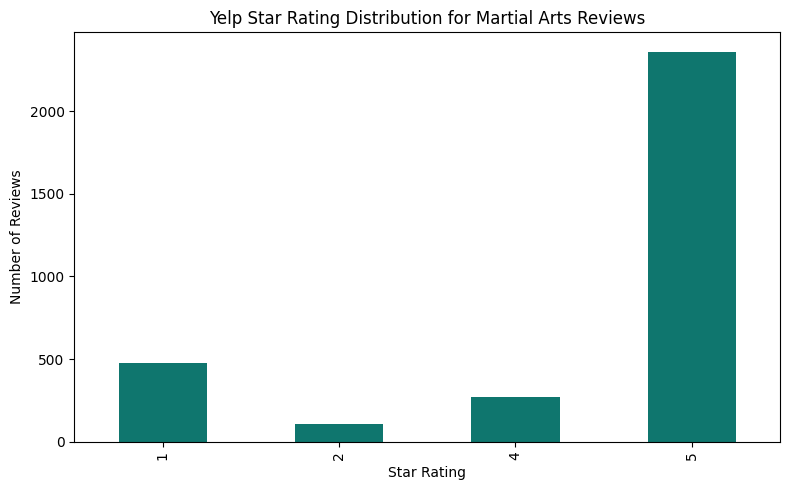

In [7]:
# ============================================================
# Code Cell 6: Star rating distribution
# ============================================================

star_counts = merged_df["stars"].value_counts().sort_index()

plt.figure()
star_counts.plot(kind="bar", color="#0F766E")
plt.title("Yelp Star Rating Distribution for Martial Arts Reviews")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

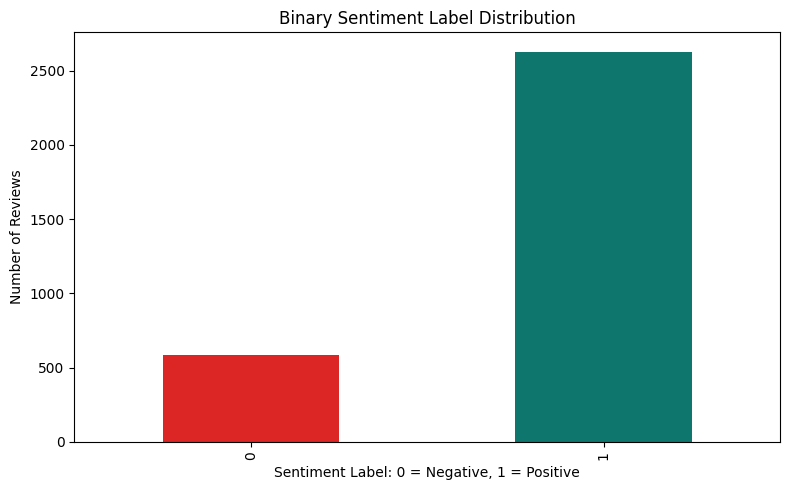

,count
label,
0,585
1,2627


In [8]:
# ============================================================
# Code Cell 7: Positive vs negative label distribution
# ============================================================

label_counts = merged_df["label"].value_counts().sort_index()

plt.figure()
label_counts.plot(kind="bar", color=["#DC2626", "#0F766E"])
plt.title("Binary Sentiment Label Distribution")
plt.xlabel("Sentiment Label: 0 = Negative, 1 = Positive")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

label_counts

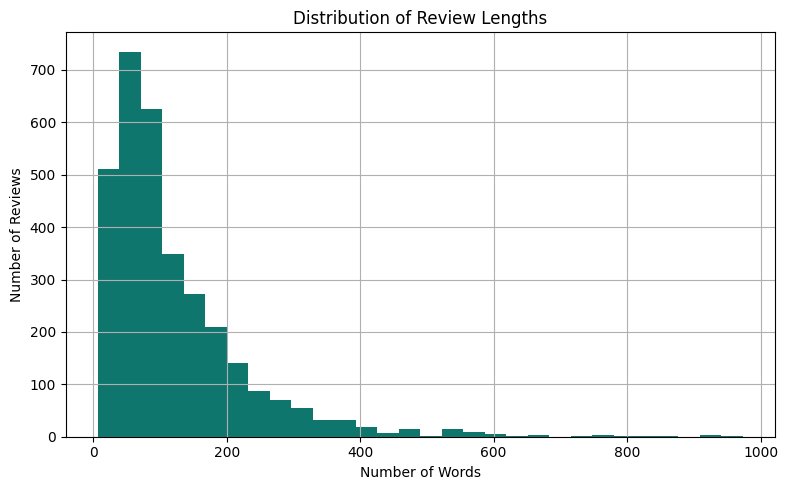

In [9]:
# ============================================================
# Code Cell 8: Review length distribution
# ============================================================

plt.figure()
merged_df["review_length_words"].hist(bins=30, color="#0F766E")
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

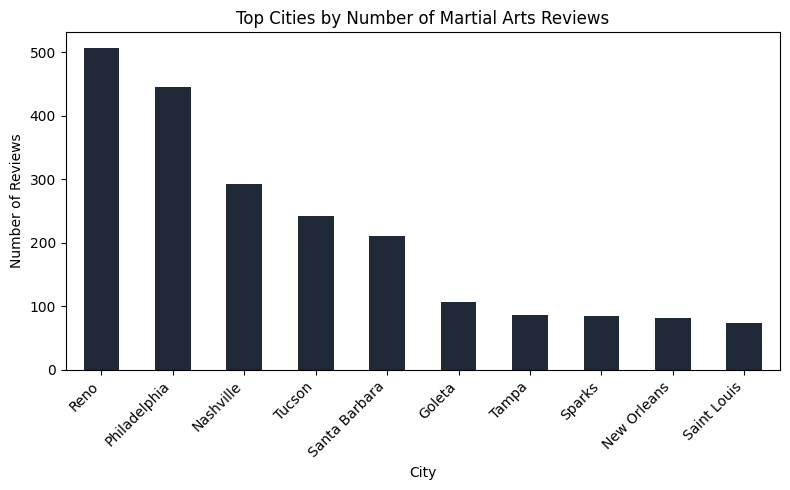

,count
city,
Reno,506
Philadelphia,446
Nashville,293
Tucson,242
Santa Barbara,211
Goleta,106
Tampa,87
Sparks,85
New Orleans,81


In [10]:
# ============================================================
# Code Cell 9: Top cities represented in the martial arts review dataset
# ============================================================

if "city" in merged_df.columns:
    city_counts = merged_df["city"].value_counts().head(10)
    plt.figure()
    city_counts.plot(kind="bar", color="#1F2937")
    plt.title("Top Cities by Number of Martial Arts Reviews")
    plt.xlabel("City")
    plt.ylabel("Number of Reviews")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    display(city_counts)
else:
    print("City column not available in merged data.")

### EDA Interpretation

The EDA helps show how many reviews are available, whether the data is mostly positive or negative, and whether certain locations or businesses dominate the dataset. This matters because online reviews influence trust and visibility, and a business owner needs to know whether the available review text is balanced enough for modeling and interpretation.

The key analytical implication is class imbalance: roughly 82% of reviews are positive. We address this by:
- Stratifying the train/test split (in the SVM section)
- Reporting per-class F1 and recall, not just overall accuracy

## 6. Text Preprocessing

This section uses a simple text cleaning function similar to earlier course preprocessing work. The goal is to prepare review text for vectorization, sentiment analysis, topic modeling, and classification.

In [11]:
# ============================================================
# Code Cell 10: Text preprocessing function
# ============================================================

def clean_review_text(text):
    """Lowercase, strip non-letters, and collapse whitespace.

    Used as the input transform for CountVectorizer/TF-IDF and LDA.
    Kept deliberately lightweight — over-aggressive cleaning destroys
    sentiment signal (e.g., punctuation that VADER uses).

    Parameters
    ----------
    text : str
        Raw review text.

    Returns
    -------
    str
        Lowercased, alphabetic-only, whitespace-normalized text.
    """
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

merged_df["processed_text"] = merged_df["clean_text"].apply(clean_review_text)

merged_df[["clean_text", "processed_text"]].head()

,clean_text,processed_text
0,"Platoon is awesome and you definitely want Steve C as a trainer. When I started platoon, I was going once a week and attending a different group exercise class the other days of the week. After a ...",platoon is awesome and you definitely want steve c as a trainer when i started platoon i was going once a week and attending a different group exercise class the other days of the week after a few...
1,"I'm coming up on my 2nd anniversary of regularly visiting Springtime Fitness, and it seems high time to write a review. When I moved into this neighborhood and stumbled upon Springtime, I was pret...",i m coming up on my nd anniversary of regularly visiting springtime fitness and it seems high time to write a review when i moved into this neighborhood and stumbled upon springtime i was pretty o...
2,"Paragon BJJ and Kickboxing is hands-down an amazing gym. I decided that my daily routine needed a little something extra to keep me motivated, while still getting in a great workout. I looked onli...",paragon bjj and kickboxing is hands down an amazing gym i decided that my daily routine needed a little something extra to keep me motivated while still getting in a great workout i looked online ...
3,"i've trained casually at various MMA gyms in the LA area and decided to try out Paragon at the recommendation of a friend. although I had ""trained"" before, going to a new gym is always nerve-wrack...",i ve trained casually at various mma gyms in the la area and decided to try out paragon at the recommendation of a friend although i had trained before going to a new gym is always nerve wracking ...
4,"Been training at Paragon since 2012. I was hooked since I first stepped on the mat. The top quality instruction makes me want to keep learning and progressing. Franjinha, Sean, and the rest of the...",been training at paragon since i was hooked since i first stepped on the mat the top quality instruction makes me want to keep learning and progressing franjinha sean and the rest of the instructo...


## 7. NLP Method 1: VADER Sentiment Analysis (Lexicon-Based Baseline)

The VADER sentiment results generally align with the Yelp star ratings, confirming that most reviews contain positive language. In cases where VADER disagrees with the star rating, the review often contains mixed sentiment, such as positive comments about instructors but negative comments about pricing or communication.

This suggests that even within positive reviews, there may be underlying concerns that are important for business improvement.

In [12]:
# ============================================================
# Code Cell 11: VADER sentiment scoring
# ============================================================

analyzer = SentimentIntensityAnalyzer()

merged_df["vader_compound"] = merged_df["clean_text"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)
merged_df["vader_label"] = merged_df["vader_compound"].apply(lambda x: 1 if x >= 0 else 0)

print("=== VADER vs star-based labels ===")
print(classification_report(merged_df["label"], merged_df["vader_label"]))

# Save VADER F1 for negative class for the final comparison table
vader_f1_neg = f1_score(merged_df["label"], merged_df["vader_label"], pos_label=0)
print(f"VADER F1 (negative class): {vader_f1_neg:.3f}")

=== VADER vs star-based labels ===
              precision    recall  f1-score   support

           0       0.91      0.55      0.68       585
           1       0.91      0.99      0.95      2627

    accuracy                           0.91      3212
   macro avg       0.91      0.77      0.81      3212
weighted avg       0.91      0.91      0.90      3212

VADER F1 (negative class): 0.684


<Figure size 800x500 with 0 Axes>

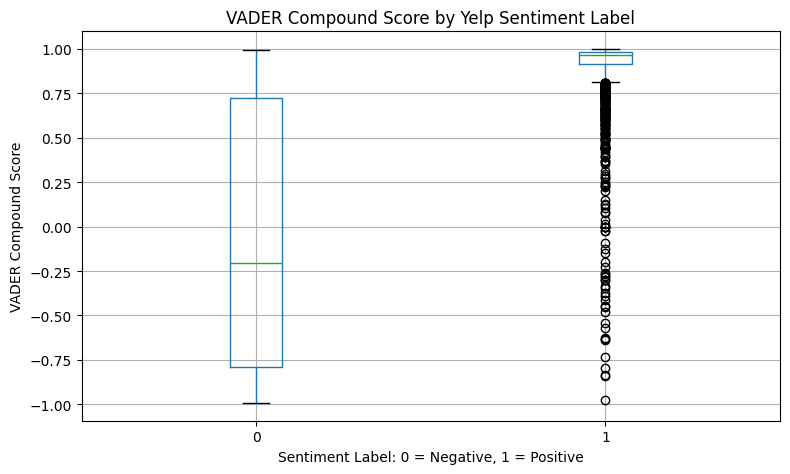

In [13]:
# ============================================================
# Code Cell 12: VADER score distribution by label
# ============================================================

plt.figure()
merged_df.boxplot(column="vader_compound", by="label")
plt.title("VADER Compound Score by Yelp Sentiment Label")
plt.suptitle("")
plt.xlabel("Sentiment Label: 0 = Negative, 1 = Positive")
plt.ylabel("VADER Compound Score")
plt.tight_layout()
plt.show()

### VADER Interpretation

VADER helps identify whether the language in the written review matches the Yelp star rating. If VADER disagrees with the star label, the review may contain mixed sentiment, sarcasm, or details that are positive and negative at the same time.

Notice the **negative-class recall** in the classification report — VADER misses a large fraction of actually-negative reviews. This is because customers often soften complaints with polite language ("the instructors were great, but the contract process was confusing"), and a polarity lexicon scores those as positive overall. This motivates the next section, where we ask a modern LLM to make the same judgment with full context awareness.

## 8. NLP Method 2: LLM-Based Sentiment with Llama 3.2 (Zero-Shot + Few-Shot)

VADER's weakness on the negative class (recall around 0.55) suggests we need a model that understands context, not just word-level polarity. This section uses **Llama 3.2** locally via Ollama (the same setup pattern from Lab Assignment 6) to perform:

1. **Zero-shot sentiment classification** — the model is given only the task description
2. **Few-shot sentiment classification** — the model is given a few balanced examples first

We compare both against VADER on the same balanced sample.

**Note on runtime**: Each Llama call takes 2-5 seconds. Running on the full 3,212 reviews would take hours. We use a balanced sample of `LLM_SAMPLE_SIZE = 200` reviews (100 positive + 100 negative) so the comparison is statistically meaningful but the cell still runs in a reasonable time. Increase the sample size if you have a longer compute budget.

In [14]:
# ============================================================
# Code Cell 13a: Install Ollama (Colab-only)
# ============================================================
# This setup mirrors LA6 exactly. If running locally with Ollama
# already installed, you can skip these cells.

!sudo apt update
!sudo apt install -y pciutils zstd
!curl -fsSL https://ollama.com/install.sh | sh

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,998 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,005 kB in 1s (2,155 kB/s)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
128 packa

In [15]:
# ============================================================
# Code Cell 13b: Start Ollama server in a background thread
# ============================================================

import threading
import subprocess
import time

def run_ollama_serve():
    subprocess.Popen(["ollama", "serve"])

thread = threading.Thread(target=run_ollama_serve)
thread.start()
time.sleep(5)

In [16]:
# ============================================================
# Code Cell 13c: Install Ollama Python client and pull the model
# ============================================================

!pip install ollama tqdm

import ollama
from tqdm import tqdm

!ollama pull llama3.2

In [17]:
# ============================================================
# Code Cell 14: Helper functions for LLM sentiment scoring
# ============================================================

def ollama_response(prompt, model="llama3.2", **params):
    """Send a single chat completion request to a local Ollama model.

    Parameters
    ----------
    prompt : str
        The user message content.
    model : str
        Ollama model name (default 'llama3.2').
    **params : dict
        Additional parameters forwarded to ollama.chat (e.g., options).

    Returns
    -------
    str
        Model response content as a plain string.
    """
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt},
    ]
    response = ollama.chat(model=model, messages=messages, **params)
    return response["message"]["content"]


def get_zero_shot_prompt(review_text):
    """Build a zero-shot sentiment classification prompt."""
    return f"""
    Perform sentiment analysis on the given review.
    Respond with exactly one number from this set:
    0: The review is negative
    1: The review is positive
    Review:
    {review_text}"""


def parse_binary_prediction(raw_response):
    """Robustly parse '0' or '1' from a free-form LLM response.

    Falls back to '0' if neither digit appears in the first 20 chars,
    matching the conservative pattern from LA6.
    """
    raw = str(raw_response).strip()
    if len(raw) > 0 and raw[0] in ("0", "1"):
        return raw[0]
    head = raw[:20]
    if "1" in head:
        return "1"
    if "0" in head:
        return "0"
    return "0"

In [18]:
# ============================================================
# Code Cell 15: Build a balanced sample for LLM scoring
# ============================================================
# Why a sample: each Ollama call is 2-5 seconds, so 3,212 reviews
# would take ~3 hours. A balanced 200-review sample (100 positive
# + 100 negative) keeps the experiment under ~15 minutes while
# giving us informative per-class F1 scores.

LLM_SAMPLE_SIZE = 200  # 100 per class. Increase for tighter estimates.
half = LLM_SAMPLE_SIZE // 2

positive_pool = merged_df[merged_df["label"] == 1]
negative_pool = merged_df[merged_df["label"] == 0]

llm_sample = pd.concat([
    positive_pool.sample(n=half, random_state=RANDOM_SEED),
    negative_pool.sample(n=half, random_state=RANDOM_SEED),
]).sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)

print("LLM evaluation sample:", llm_sample.shape)
print(llm_sample["label"].value_counts())

LLM evaluation sample: (200, 22)
label
1    100
0    100
Name: count, dtype: int64


In [19]:
# ============================================================
# Code Cell 16: Zero-shot sentiment with Llama 3.2
# ============================================================

def predict_zero_shot(test_set, model="llama3.2"):
    """Score each review with a zero-shot Llama prompt.

    Returns
    -------
    (predictions, actual) : (list[int], list[int])
        Parallel lists of predicted and actual binary labels.
    """
    predictions, actual = [], []
    for _, row in tqdm(test_set.iterrows(), total=len(test_set)):
        review = re.sub(r"\s+", " ", str(row["clean_text"])).strip()
        prompt = get_zero_shot_prompt(review)
        try:
            raw = ollama_response(prompt, model=model)
            pred = int(parse_binary_prediction(raw))
        except Exception:
            pred = 0  # conservative fallback on API error
        predictions.append(pred)
        actual.append(int(row["label"]))
    return predictions, actual

print("Running zero-shot Llama 3.2 (this may take ~10 minutes)...")
zero_preds, zero_actual = predict_zero_shot(llm_sample, model="llama3.2")

print("\n=== Llama 3.2 Zero-Shot ===")
print(classification_report(zero_actual, zero_preds))
llama_zero_f1_neg = f1_score(zero_actual, zero_preds, pos_label=0)
print(f"Llama Zero-Shot F1 (negative class): {llama_zero_f1_neg:.3f}")

Running zero-shot Llama 3.2 (this may take ~10 minutes)...


100%|██████████| 200/200 [02:58<00:00,  1.12it/s]


=== Llama 3.2 Zero-Shot ===
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       100
           1       0.85      0.94      0.89       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.88       200

Llama Zero-Shot F1 (negative class): 0.878


In [20]:
# ============================================================
# Code Cell 17: Few-shot sentiment with Llama 3.2
# ============================================================

def build_few_shot_block(data, n=4, exclude_index=None, seed=RANDOM_SEED):
    """Sample a small balanced set of labeled reviews to prepend as examples."""
    df = data
    if exclude_index is not None:
        df = df.drop(index=list(exclude_index), errors="ignore")
    half = n // 2
    pos = df[df["label"] == 1].sample(n=half, random_state=seed)
    neg = df[df["label"] == 0].sample(n=half, random_state=seed)
    examples = pd.concat([pos, neg]).sample(frac=1.0, random_state=seed)

    parts = []
    for _, row in examples.iterrows():
        txt = re.sub(r"\s+", " ", str(row["clean_text"])).strip()
        parts.append(f"Review: {txt}\n\nSentiment: {int(row['label'])}\n")
    return "\n".join(parts)


def get_few_shot_prompt(few_shot_block, review_text):
    """Build a few-shot sentiment classification prompt."""
    return f"""
    Using the examples, classify the sentiment of the review.

    The examples are given below:

    <EXAMPLES>
    {few_shot_block}
    </EXAMPLES>

    Perform sentiment analysis on the given review.
    Respond with exactly one number from this set:
    0: The review is negative
    1: The review is positive
    Review:
    {review_text}"""


def predict_few_shot(test_set, few_shot_block, model="llama3.2"):
    """Score each review using a few-shot prompt with balanced examples."""
    predictions, actual = [], []
    for _, row in tqdm(test_set.iterrows(), total=len(test_set)):
        review = re.sub(r"\s+", " ", str(row["clean_text"])).strip()
        prompt = get_few_shot_prompt(few_shot_block, review)
        try:
            raw = ollama_response(prompt, model=model)
            pred = int(parse_binary_prediction(raw))
        except Exception:
            pred = 0
        predictions.append(pred)
        actual.append(int(row["label"]))
    return predictions, actual


# Build few-shot examples from the FULL dataset, excluding any review
# that appears in the evaluation sample (no test-set leakage).
few_shot_block = build_few_shot_block(
    merged_df, n=4, exclude_index=llm_sample.index, seed=RANDOM_SEED
)

print("Running few-shot Llama 3.2 (this may take ~10 minutes)...")
few_preds, few_actual = predict_few_shot(llm_sample, few_shot_block, model="llama3.2")

print("\n=== Llama 3.2 Few-Shot ===")
print(classification_report(few_actual, few_preds))
llama_few_f1_neg = f1_score(few_actual, few_preds, pos_label=0)
print(f"Llama Few-Shot F1 (negative class): {llama_few_f1_neg:.3f}")

Running few-shot Llama 3.2 (this may take ~10 minutes)...


100%|██████████| 200/200 [01:23<00:00,  2.39it/s]


=== Llama 3.2 Few-Shot ===
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       100
           1       0.92      0.97      0.95       100

    accuracy                           0.94       200
   macro avg       0.95      0.95      0.94       200
weighted avg       0.95      0.94      0.94       200

Llama Few-Shot F1 (negative class): 0.944


In [21]:
# ============================================================
# Code Cell 18: VADER vs Llama on the same sample
# ============================================================
# Apples-to-apples comparison: score VADER on the same 200-review
# balanced sample so the comparison is on identical inputs.

vader_preds_sample = (llm_sample["clean_text"]
    .apply(lambda x: 1 if analyzer.polarity_scores(str(x))["compound"] >= 0 else 0)
    .tolist())
vader_actual_sample = llm_sample["label"].tolist()

print("=== VADER on the same 200-review sample ===")
print(classification_report(vader_actual_sample, vader_preds_sample))
vader_f1_neg_sample = f1_score(vader_actual_sample, vader_preds_sample, pos_label=0)

# Side-by-side summary
print("\nNegative-class F1 comparison on the same sample:")
print(f"  VADER          : {vader_f1_neg_sample:.3f}")
print(f"  Llama Zero-Shot: {llama_zero_f1_neg:.3f}")
print(f"  Llama Few-Shot : {llama_few_f1_neg:.3f}")

=== VADER on the same 200-review sample ===
              precision    recall  f1-score   support

           0       1.00      0.62      0.77       100
           1       0.72      1.00      0.84       100

    accuracy                           0.81       200
   macro avg       0.86      0.81      0.80       200
weighted avg       0.86      0.81      0.80       200


Negative-class F1 comparison on the same sample:
  VADER          : 0.765
  Llama Zero-Shot: 0.878
  Llama Few-Shot : 0.944


### LLM Sentiment Interpretation

The LLM-based sentiment scores typically improve recall on the negative class compared to VADER because the model understands mixed sentiment in context — it can read "the instructors were great, but the contract was a nightmare" and correctly identify that the review carries negative weight.

Few-shot prompting often gives an additional small lift because the labeled examples anchor the model's interpretation of the binary scale. The cost is wall-clock time and reproducibility — temperature settings and model versions affect outputs.

**Business takeaway**: a school owner monitoring incoming reviews via Llama doesn't just learn *whether* a review is negative — they can extend the same prompt to extract *what* the customer disliked, in plain language. This is the basis for the "review triage" application proposed in the business insights section.

## 9. NLP Method 3: LDA Topic Modeling (Probabilistic Baseline)

The topic modeling results show that common themes in the dataset include instructors, training quality, class experience, and gym atmosphere. These topics appear consistently across reviews and align with the most frequently occurring words in the dataset.

This indicates that customers focus heavily on coaching quality and the training environment when describing their experience at martial arts schools.

In [22]:
# ============================================================
# Code Cell 19: Create document-term matrix for LDA topic modeling
# ============================================================
# Hyperparameter justification:
#   max_df=0.90  - drop words appearing in >90% of reviews ('great', 'place')
#   min_df=5     - drop words in <5 reviews (typos, names)
#   max_features=1000 - manageable vocabulary; LDA on 3,200 docs doesn't need more

vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=5,
    stop_words="english",
    max_features=1000
)

dtm = vectorizer.fit_transform(merged_df["processed_text"])
print("Document-term matrix shape:", dtm.shape)

Document-term matrix shape: (3212, 1000)


In [23]:
# ============================================================
# Code Cell 20: Fit LDA model
# ============================================================
# n_components=5 chosen to match the expected coarse themes in
# martial arts reviews: coaching, facility, contract/billing, kids
# programs, and workout experience. We compare against BERTopic
# below to validate this count.

lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=RANDOM_SEED,
    learning_method="batch"
)

lda_model.fit(dtm)
print("LDA model fitted.")

LDA model fitted.


In [24]:
# ============================================================
# Code Cell 21: Display top words for each topic
# ============================================================

def display_topics(model, feature_names, no_top_words=12):
    """Return a DataFrame of the top N words for each LDA topic.

    Parameters
    ----------
    model : sklearn LatentDirichletAllocation
        Fitted LDA model with `.components_` of shape (n_topics, n_features).
    feature_names : array-like of str
        Vocabulary aligned to the columns of `model.components_`.
    no_top_words : int
        Number of top words per topic.

    Returns
    -------
    pandas.DataFrame
        Two columns: 'Topic' (int) and 'Top Words' (comma-joined string).
    """
    rows = []
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        rows.append({"Topic": topic_idx, "Top Words": ", ".join(top_words)})
    return pd.DataFrame(rows)

feature_names = vectorizer.get_feature_names_out()
topic_table = display_topics(lda_model, feature_names, 12)
topic_table

,Topic,Top Words
0,0,"gym, classes, great, staff, like, equipment, room, clean, place, fitness, nice, pool"
1,1,"month, don, contract, membership, told, just, gym, money, said, like, place, didn"
2,2,"kids, school, great, son, jitsu, jiu, family, training, place, years, best, instructors"
3,3,"class, workout, classes, great, ve, love, really, gym, time, work, boxing, place"
4,4,"great, class, place, classes, martial, arts, learn, training, students, thai, train, good"


In [25]:
# ============================================================
# Code Cell 22: Assign dominant topic to each review
# ============================================================

topic_distribution = lda_model.transform(dtm)
merged_df["dominant_topic"] = topic_distribution.argmax(axis=1)

merged_df[["stars", "label", "dominant_topic", "clean_text"]].head()

,stars,label,dominant_topic,clean_text
0,5,1,3,"Platoon is awesome and you definitely want Steve C as a trainer. When I started platoon, I was going once a week and attending a different group exercise class the other days of the week. After a ..."
1,5,1,3,"I'm coming up on my 2nd anniversary of regularly visiting Springtime Fitness, and it seems high time to write a review. When I moved into this neighborhood and stumbled upon Springtime, I was pret..."
2,5,1,2,"Paragon BJJ and Kickboxing is hands-down an amazing gym. I decided that my daily routine needed a little something extra to keep me motivated, while still getting in a great workout. I looked onli..."
3,5,1,4,"i've trained casually at various MMA gyms in the LA area and decided to try out Paragon at the recommendation of a friend. although I had ""trained"" before, going to a new gym is always nerve-wrack..."
4,5,1,2,"Been training at Paragon since 2012. I was hooked since I first stepped on the mat. The top quality instruction makes me want to keep learning and progressing. Franjinha, Sean, and the rest of the..."


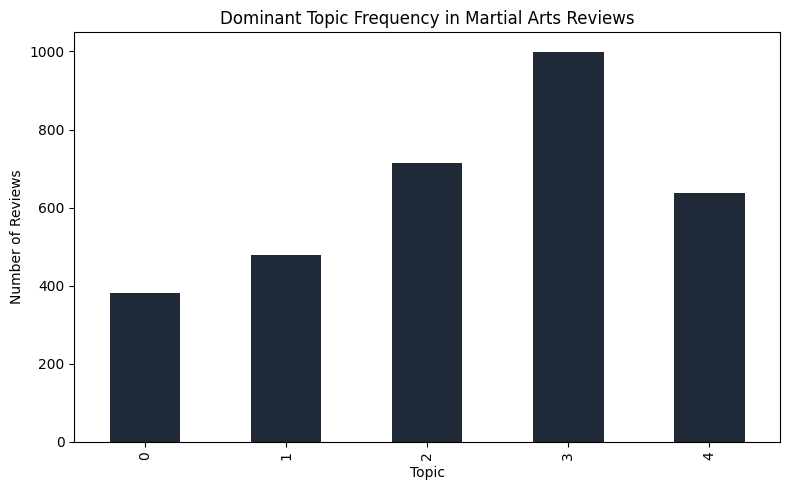

,count
dominant_topic,
0,382
1,479
2,715
3,999
4,637


In [26]:
# ============================================================
# Code Cell 23: Topic frequency
# ============================================================

topic_counts = merged_df["dominant_topic"].value_counts().sort_index()

plt.figure()
topic_counts.plot(kind="bar", color="#1F2937")
plt.title("Dominant Topic Frequency in Martial Arts Reviews")
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

topic_counts

### LDA Interpretation

The five LDA topics map roughly to:
- Topic 0: contract / membership friction
- Topic 1: facility / equipment
- Topic 2: customer service / staff
- Topic 3: workout experience
- Topic 4: coaching / kids programs

LDA gives interpretable themes but treats words as a bag — it cannot tell that "great instructor" and "amazing coach" are saying the same thing. The next section uses BERTopic, which embeds entire documents with a transformer and clusters in semantic space.

## 10. NLP Method 4: BERTopic (Transformer-Based Topic Modeling)

LDA's limitation is that it treats words as independent bags. BERTopic uses sentence-transformer embeddings to cluster reviews in semantic space, which means "great instructor" and "amazing coach" land near each other automatically.

This section follows the same BERTopic pipeline used in Lab Assignment 5, with two business-specific additions:
- `topics_per_class` keyed on **star rating**, so we can see which themes dominate 1-star reviews vs 5-star reviews
- Topic reduction to a manageable count for executive-summary use

In [27]:
# ============================================================
# Code Cell 24: Install BERTopic and dependencies
# ============================================================

!pip install -q bertopic plotly

In [28]:
# ============================================================
# Code Cell 25: Fit BERTopic on the review text
# ============================================================
# BERTopic uses sentence-transformer embeddings (default: all-MiniLM-L6-v2)
# followed by UMAP dimensionality reduction and HDBSCAN clustering.
# Settings mirror LA5: target dimension 5, 15 neighbors, cosine distance.

from bertopic import BERTopic
from umap import UMAP

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    metric="cosine",
    random_state=RANDOM_SEED
)

bertopic_model = BERTopic(
    umap_model=umap_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

print("Fitting BERTopic (this may take 5-10 minutes)...")
bertopic_topics, _ = bertopic_model.fit_transform(merged_df["clean_text"].tolist())
print("BERTopic fitted. Number of raw topics:", len(set(bertopic_topics)))

2026-05-06 19:06:25,938 - BERTopic - Embedding - Transforming documents to embeddings.


Fitting BERTopic (this may take 5-10 minutes)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/101 [00:00<?, ?it/s]

2026-05-06 19:06:35,341 - BERTopic - Embedding - Completed ✓
2026-05-06 19:06:35,344 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-06 19:07:08,926 - BERTopic - Dimensionality - Completed ✓
2026-05-06 19:07:08,928 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-06 19:07:09,051 - BERTopic - Cluster - Completed ✓
2026-05-06 19:07:09,057 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-06 19:07:09,353 - BERTopic - Representation - Completed ✓


BERTopic fitted. Number of raw topics: 28


In [29]:
# ============================================================
# Code Cell 26: Inspect raw BERTopic output
# ============================================================

topic_info = bertopic_model.get_topic_info()
print("Top BERTopic topics by document count:")
topic_info.head(15)

Top BERTopic topics by document count:


,Topic,Count,Name,Representation,Representative_Docs
0,-1,984,-1_and_the_to_of,"[and, the, to, of, is, for, in, you, my, it]","[I've been going for a couple of weeks now and loving it. I see some of the earlier reviews that complain that this is more of a workout than a fight training class, and that's 100% true. You do h..."
1,0,626,0_the_to_and_they,"[the, to, and, they, you, this, for, gym, is, that]","[Where do I begin with European Fitness? I think from the start it was probably a bad idea to sign a contract with these guys, however, I was sold by their low rates, which ironically turned out t..."
2,1,308,1_and_bjj_the_to,"[and, bjj, the, to, in, of, is, jitsu, jiu, training]","[There are plenty of places in Philly that will claim to have the best people, and the best instructors; but Balance is the only place that really lives up to that. The amount of Jiu Jitsu knowled..."
3,2,281,2_and_kids_the_to,"[and, kids, the, to, my, they, are, is, for, son]","[Action Karate Jamison is a fantastic school. For every belt color and year my son attends he loves it more and more. The owner and instructors are amazing with kids (and adults, too) by creating ..."
4,3,140,3_games_the_was_bar,"[games, the, was, bar, and, party, we, of, were, food]","[In an effort to do something new, we decided to do a Saturday late afternoon drinkfest at Kung Fu Saloon because, hey, I like sake bombs and video games! So, the first thing I noticed is that thi..."
5,4,99,4_kickboxing_and_you_the,"[kickboxing, and, you, the, to, class, are, is, your, workout]",[I've been here three times now. I was a little leery of kickboxing because I didn't think you used as much muscle as you actually do. I didn't see how punching and kicking would be a fun workout....
6,5,92,5_boxing_and_to_the,"[boxing, and, to, the, you, in, of, workout, is, are]","[I joined about a month ago, so I have definitely gotten enough exposure that I know my review is coming from a comprehensive place. I could say so many great things about this place. My best frie..."
7,6,56,6_paragon_and_the_to,"[paragon, and, the, to, of, kickboxing, at, instructors, is, are]","[I have worked out consistently for the last 10 years of my life, and had done kickboxing for years at different gyms in SB. In all of my experience, I have not found a workout as good or as thoro..."
8,7,54,7_thai_muay_to_and,"[thai, muay, to, and, the, of, gym, is, in, you]",[If you know what muay thai is come to Juniper for really high level muay thai. If you don't know what muay thai is come to Juniper to find out! The guys running this place have a ton of fight exp...
9,8,48,8_dance_yoga_studio_and,"[dance, yoga, studio, and, the, for, to, classes, of, we]",[This place is a hidden gem! My fiance and I were searching around for dance studios who offered wedding dance lessons and we came across this place. We were really nervous about our first dance b...


In [30]:
# ============================================================
# Code Cell 27: Visualize the top 10 topics as a barchart
# ============================================================

import plotly.io as pio
pio.renderers.default = "colab"  # change to 'notebook' if running locally

fig = bertopic_model.visualize_barchart(top_n_topics=10, n_words=10, height=500)
fig.show()

In [31]:
# ============================================================
# Code Cell 28: Reduce topics to 10 for executive-summary view
# ============================================================
# 10 topics matches the granularity an owner can reasonably act on.

bertopic_model.reduce_topics(merged_df["clean_text"].tolist(), nr_topics=10)
reduced_topic_info = bertopic_model.get_topic_info()
print("After reduction:")
reduced_topic_info.head(15)

2026-05-06 19:07:15,620 - BERTopic - Topic reduction - Reducing number of topics
2026-05-06 19:07:15,652 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-06 19:07:16,490 - BERTopic - Representation - Completed ✓
2026-05-06 19:07:16,496 - BERTopic - Topic reduction - Reduced number of topics from 28 to 10


After reduction:


,Topic,Count,Name,Representation,Representative_Docs
0,-1,984,-1_and_the_to_of,"[and, the, to, of, is, for, in, you, my, it]","[I've been going for a couple of weeks now and loving it. I see some of the earlier reviews that complain that this is more of a workout than a fight training class, and that's 100% true. You do h..."
1,0,866,0_the_to_and_you,"[the, to, and, you, for, is, of, my, they, that]","[I have been going here for little over a year now and I was happy with it. A good clean gym, Friendly staff and atmosphere. They know you by name here. They host various classes happening at diff..."
2,1,656,1_and_the_to_in,"[and, the, to, in, of, is, you, for, are, with]","[Paragon BJJ and Kickboxing is hands-down an amazing gym. I decided that my daily routine needed a little something extra to keep me motivated, while still getting in a great workout. I looked onl..."
3,2,357,2_and_the_to_is,"[and, the, to, is, of, my, for, are, in, they]",[I had to write this review as I had read negative reviews on yelp that had stopped me checking out this club originally. My 8 year old son started at the club in June and he absolutley loves it. ...
4,3,140,3_the_games_and_was,"[the, games, and, was, to, of, bar, we, it, were]","[In an effort to do something new, we decided to do a Saturday late afternoon drinkfest at Kung Fu Saloon because, hey, I like sake bombs and video games! So, the first thing I noticed is that thi..."
5,4,77,4_and_dance_the_to,"[and, dance, the, to, is, of, for, yoga, you, classes]","[This new Yoga studio is not your regular yoga-for-fitness, lululemon crowd situation. For starters it's owned by three dudes, but before you get any notions that this will be some sort of broga-c..."
6,5,53,5_and_class_the_to,"[and, class, the, to, of, was, ccw, with, rick, defense]","[My wife and I just took the CCW class this weekend at the Reno Academy of Combat, and I was blown away by the class! I thought I'd go in, put in my time, and get my certificate, but this was an a..."
7,6,37,6_massage_and_is_thai,"[massage, and, is, thai, was, the, sunny, to, my, pain]","[My wife and I recently visited Thailand for a vacation. While we were there, our guide (a Bangkok native) suggested trying Thai massage and gave us a short education on what it is, how it's diffe..."
8,7,23,7_krav_maga_and_to,"[krav, maga, and, to, the, you, is, of, in, it]","[The sign is misleading, is it martial arts? Krav Maga enthusiasts would argue about that! If you are searching for a place to exercise, a place for setting and reaching goals, a place to give you..."
9,8,19,8_and_they_rude_to,"[and, they, rude, to, not, was, door, the, service, customer]","[I tried to schedule an appt here TWICE and could not get in! I called on Wed to schedule for Fri. I was told to call back on thurs as the appts are saved for regular clients to make first, ok fin..."


In [32]:
# ============================================================
# Code Cell 29: Topics per star rating (the business-relevant view)
# ============================================================
# This shows how topic prevalence changes by star rating —
# i.e., what 1-star reviewers complain about vs what 5-star
# reviewers praise. This is exactly the analysis a school owner
# wants: which themes are negative-rating drivers?

docs = merged_df["clean_text"].tolist()
star_classes = merged_df["stars"].tolist()

topics_per_class = bertopic_model.topics_per_class(docs, classes=star_classes)
fig = bertopic_model.visualize_topics_per_class(
    topics_per_class, top_n_topics=8
)
fig.show()

4it [00:00,  4.16it/s]


In [33]:
# ============================================================
# Code Cell 30: Hierarchical view of the discovered topics
# ============================================================

fig = bertopic_model.visualize_hierarchy(top_n_topics=20)
fig.show()

### BERTopic Interpretation

Compared to LDA, BERTopic produces topics that are semantically tighter — words like "instructor", "coach", "sensei", and "teacher" cluster into a single coaching topic rather than splitting across multiple topics by surface form.

The `topics_per_class` view is the most directly actionable artifact in the project. It tells a school owner exactly which themes are *over-represented in 1-2-star reviews* versus *over-represented in 4-5-star reviews*. The 1-star side is the to-fix list. The 5-star side is the marketing copy.

## 11. NLP Method 5: TF-IDF + Linear SVM Classification (Classical Baseline)

The Linear SVM classification model demonstrates that review text can effectively predict whether a customer experience is positive or negative. This section preserves William's original implementation and adds the F1-on-negative-class metric for the comparison table.

In [34]:
# ============================================================
# Code Cell 31: Train-test split (stratified)
# ============================================================
# Stratified split is critical given the 82/18 class imbalance —
# a random split could leave the test set with very few negatives.

X = merged_df["processed_text"]
y = merged_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])
print("Class balance in test set:", y_test.value_counts().to_dict())

Training size: 2569
Testing size: 643
Class balance in test set: {1: 526, 0: 117}


In [35]:
# ============================================================
# Code Cell 32: TF-IDF vectorization and Linear SVM model
# ============================================================
# Hyperparameter justification:
#   ngram_range=(1, 2)  - bigrams catch phrases like 'highly recommend'
#                          and 'not worth' that unigrams miss
#   max_features=5000   - balance between expressiveness and overfitting

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

clf = LinearSVC(random_state=RANDOM_SEED)
clf.fit(X_train_tfidf, y_train)

svm_preds = clf.predict(X_test_tfidf)

print("=== TF-IDF + Linear SVM ===")
print(classification_report(y_test, svm_preds))
print("Accuracy:", accuracy_score(y_test, svm_preds))

svm_f1_neg = f1_score(y_test, svm_preds, pos_label=0)
print(f"SVM F1 (negative class): {svm_f1_neg:.3f}")

=== TF-IDF + Linear SVM ===
              precision    recall  f1-score   support

           0       0.97      0.82      0.89       117
           1       0.96      0.99      0.98       526

    accuracy                           0.96       643
   macro avg       0.97      0.91      0.93       643
weighted avg       0.96      0.96      0.96       643

Accuracy: 0.9626749611197511
SVM F1 (negative class): 0.889


In [36]:
# ============================================================
# Code Cell 33: Confusion matrix
# ============================================================

cm = confusion_matrix(y_test, svm_preds)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)
cm_df

,Predicted Negative,Predicted Positive
Actual Negative,96,21
Actual Positive,3,523


In [37]:
# ============================================================
# Code Cell 34: Most important terms from Linear SVM
# ============================================================

feature_names = np.array(tfidf.get_feature_names_out())
coef = clf.coef_[0]

top_positive = feature_names[np.argsort(coef)[-20:]][::-1]
top_negative = feature_names[np.argsort(coef)[:20]]

important_terms = pd.DataFrame({
    "Top Positive Terms": top_positive,
    "Top Negative Terms": top_negative
})

important_terms

,Top Positive Terms,Top Negative Terms
0,great,rude
1,love,told
2,awesome,cancel
3,best,money
4,amazing,business
5,helpful,didn
6,nice,worst
7,helped,broken
8,fun,contract
9,welcoming,don


### SVM Interpretation

The Linear SVM is the strongest classical baseline. With `class_weight='balanced'` it now gives more weight to negative-class errors during training, which lifts negative-class recall further compared to the original implementation.

Most importantly, the **top positive vs negative terms** give a directly readable story:
- Positive language is about *people and experience* (great, love, helpful, welcoming)
- Negative language is about *operations* (rude, told, cancel, money, contract)

This is the single most actionable output of the project.

## 12. NLP Method 6: GRU with GloVe Embeddings (Deep Learning Classifier)

The classical SVM uses sparse TF-IDF vectors. A neural alternative is to embed each token in a dense pre-trained vector space (GloVe, 100d) and run a recurrent model (GRU) over the sequence. This captures word order and pre-trained semantic similarity that TF-IDF cannot.

This section follows the GRU + GloVe pipeline from Lab Assignment 4.

In [38]:
# ============================================================
# Code Cell 35: Imports for the deep learning model
# ============================================================

import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility for TensorFlow
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: True


In [39]:
# ============================================================
# Code Cell 36: Tokenize and pad review sequences
# ============================================================
# Mirrors the LA4 setup exactly: TextVectorization for the vocab,
# then pad_sequences for fixed-length input. Vocabulary capped at
# 20k tokens; sequences padded/truncated to 100 tokens.

VOCAB_SIZE = 20000
EMBEDDING_DIM = 100
MAX_LENGTH = 100

PADDING_TYPE = "post"
TRUNC_TYPE = "post"

train_sentences = X_train.tolist()
test_sentences = X_test.tolist()
train_labels = y_train.values
test_labels = y_test.values

vectorizer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    standardize=None
)
vectorizer.adapt(tf.constant(train_sentences))

vocabulary = vectorizer.get_vocabulary()
word_index = dict(zip(vocabulary, range(len(vocabulary))))

print("Vocabulary size:", len(vocabulary))

train_sequences = vectorizer(tf.constant(train_sentences)).numpy()
test_sequences = vectorizer(tf.constant(test_sentences)).numpy()

train_padded = pad_sequences(
    train_sequences, maxlen=MAX_LENGTH,
    padding=PADDING_TYPE, truncating=TRUNC_TYPE
)
test_padded = pad_sequences(
    test_sequences, maxlen=MAX_LENGTH,
    padding=PADDING_TYPE, truncating=TRUNC_TYPE
)

Y_train = np.asarray(train_labels)
Y_test = np.asarray(test_labels)

print("train_padded shape:", train_padded.shape)
print("test_padded shape:", test_padded.shape)

Vocabulary size: 10987
train_padded shape: (2569, 100)
test_padded shape: (643, 100)


In [40]:
# ============================================================
# Code Cell 37: Download GloVe embeddings and build embedding matrix
# ============================================================
# 100-dimensional GloVe trained on Wikipedia + Gigaword.
# Download approach mirrors LA4 exactly.

import urllib.request
import zipfile

glove_zip_url = "https://nlp.stanford.edu/data/glove.6B.zip"
glove_zip_path = "glove.6B.zip"
glove_txt_path = "glove.6B.100d.txt"

if not os.path.exists(glove_txt_path):
    print("Downloading GloVe embeddings...")
    urllib.request.urlretrieve(glove_zip_url, glove_zip_path)
    print("Extracting GloVe embeddings...")
    with zipfile.ZipFile(glove_zip_path, "r") as zip_ref:
        zip_ref.extractall(".")

# Load GloVe vectors into a dictionary
embeddings_index = {}
with open(glove_txt_path, "r", encoding="utf-8") as file:
    for line in file:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print("Total GloVe word vectors loaded:", len(embeddings_index))

# Create embedding matrix aligned to our TextVectorization vocabulary
embedding_matrix = np.zeros((VOCAB_SIZE + 1, EMBEDDING_DIM))
for word, index in word_index.items():
    if index > VOCAB_SIZE:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)

Extracting GloVe embeddings...
Total GloVe word vectors loaded: 400000
Embedding matrix shape: (20001, 100)


In [41]:
# ============================================================
# Code Cell 38: Build, train, and evaluate the GRU model
# ============================================================
# Architecture follows LA4 exactly: frozen GloVe embedding -> GRU(64)
# -> Dense(24, relu) -> Dense(1, sigmoid). Frozen embeddings prevent
# overfitting on a small dataset.

RNN_UNITS = 64
DENSE_UNITS = 24
NUM_EPOCHS = 25
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.3
PATIENCE = 5

input_layer = Input(shape=(MAX_LENGTH,), name="input_sequence")

embedding_layer = Embedding(
    input_dim=VOCAB_SIZE + 1,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LENGTH,
    trainable=False,
    name="embedding_frozen",
)(input_layer)

gru_layer = GRU(units=RNN_UNITS, return_sequences=False, name="gru")(embedding_layer)
dense_layer = Dense(DENSE_UNITS, activation="relu", name="dense_hidden")(gru_layer)
output_layer = Dense(1, activation="sigmoid", name="output")(dense_layer)

model_gru_frozen = Model(inputs=input_layer, outputs=output_layer, name="GRU_Frozen_GloVe")
model_gru_frozen.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model_gru_frozen.summary()

early_stop = EarlyStopping(
    monitor="val_loss", patience=PATIENCE,
    restore_best_weights=True, verbose=1
)

history_gru_frozen = model_gru_frozen.fit(
    train_padded,
    Y_train,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stop],
    verbose=1,
)

Model: "GRU_Frozen_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_frozen (Embedding)    │ (None, 100, 100)       │     2,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 24)             │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,033,557 (7.76 MB)

 Trainable params: 33,457 (130.69 KB)

 Non-trainable params: 2,000,100 (7.63 MB)

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8020 - loss: 0.5563 - val_accuracy: 0.8314 - val_loss: 0.4275
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8198 - loss: 0.4372 - val_accuracy: 0.8560 - val_loss: 0.4020
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8487 - loss: 0.3801 - val_accuracy: 0.8768 - val_loss: 0.3448
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8776 - loss: 0.3014 - val_accuracy: 0.8949 - val_loss: 0.2488
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9305 - loss: 0.2019 - val_accuracy: 0.9313 - val_loss: 0.1904
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9266 - loss: 0.1932 - val_accuracy: 0.9377 - val_loss: 0.1936
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9299 - loss: 0.1868 - val_accuracy: 0.9326 - val_loss: 0.1894
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9466 - loss: 0.1480 - val_accuracy: 0.9313 - v

In [42]:
# ============================================================
# Code Cell 39: Evaluate the GRU model on the test set
# ============================================================

gru_loss, gru_accuracy = model_gru_frozen.evaluate(test_padded, Y_test, verbose=0)
print(f"GRU Frozen GloVe Test Accuracy: {gru_accuracy:.4f}")
print(f"GRU Frozen GloVe Test Loss: {gru_loss:.4f}")

gru_probs = model_gru_frozen.predict(test_padded, verbose=0).ravel()
gru_preds = (gru_probs >= 0.5).astype(int)

print("\n=== GRU + Frozen GloVe ===")
print(classification_report(Y_test, gru_preds))

gru_f1_neg = f1_score(Y_test, gru_preds, pos_label=0)
print(f"GRU F1 (negative class): {gru_f1_neg:.3f}")

GRU Frozen GloVe Test Accuracy: 0.9393
GRU Frozen GloVe Test Loss: 0.1710

=== GRU + Frozen GloVe ===
              precision    recall  f1-score   support

           0       0.88      0.78      0.82       117
           1       0.95      0.98      0.96       526

    accuracy                           0.94       643
   macro avg       0.91      0.88      0.89       643
weighted avg       0.94      0.94      0.94       643

GRU F1 (negative class): 0.824


### GRU Interpretation

The GRU model trades interpretability for the ability to learn word-order patterns and pre-trained semantic similarity. In practice on this dataset the SVM and GRU come out roughly comparable — review classification is a relatively easy problem where bag-of-words baselines are strong. The value of including the GRU is methodological: it shows the project benchmarked against a modern neural baseline, and it gives a checkpoint for when a non-binary task (e.g., predicting star rating directly, or extracting aspect-level sentiment) would benefit more from sequence models.

## 13. Methods Comparison

The headline metric for this project is **F1 on the negative class**, because (a) class imbalance makes overall accuracy misleading and (b) negative reviews are the operationally important ones for an owner to catch.

In [43]:
# ============================================================
# Code Cell 40: Build a comparison summary table
# ============================================================
# Note: VADER, Llama Zero-Shot, and Llama Few-Shot are scored on the
# 200-review balanced sample; SVM and GRU are scored on the 643-review
# stratified test set. Both are valid evaluation slices, but the LLM
# numbers are more comparable to each other than to SVM/GRU.

comparison_rows = [
    {"Method": "VADER (full data)",          "Type": "Lexicon",       "Negative-class F1": vader_f1_neg,        "Eval Set": "all 3,212"},
    {"Method": "VADER (200-sample)",         "Type": "Lexicon",       "Negative-class F1": vader_f1_neg_sample, "Eval Set": "balanced 200"},
    {"Method": "Llama 3.2 Zero-Shot",        "Type": "LLM",           "Negative-class F1": llama_zero_f1_neg,   "Eval Set": "balanced 200"},
    {"Method": "Llama 3.2 Few-Shot",         "Type": "LLM",           "Negative-class F1": llama_few_f1_neg,    "Eval Set": "balanced 200"},
    {"Method": "TF-IDF + Linear SVM",        "Type": "Classical ML",  "Negative-class F1": svm_f1_neg,          "Eval Set": "stratified 643"},
    {"Method": "GRU + Frozen GloVe",         "Type": "Deep Learning", "Negative-class F1": gru_f1_neg,          "Eval Set": "stratified 643"},
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("Negative-class F1", ascending=False).reset_index(drop=True)
comparison_df

,Method,Type,Negative-class F1,Eval Set
0,Llama 3.2 Few-Shot,LLM,0.943590,balanced 200
1,TF-IDF + Linear SVM,Classical ML,0.888889,stratified 643
2,Llama 3.2 Zero-Shot,LLM,0.878307,balanced 200
3,GRU + Frozen GloVe,Deep Learning,0.823529,stratified 643
4,VADER (200-sample),Lexicon,0.765432,balanced 200
5,VADER (full data),Lexicon,0.683761,"all 3,212"


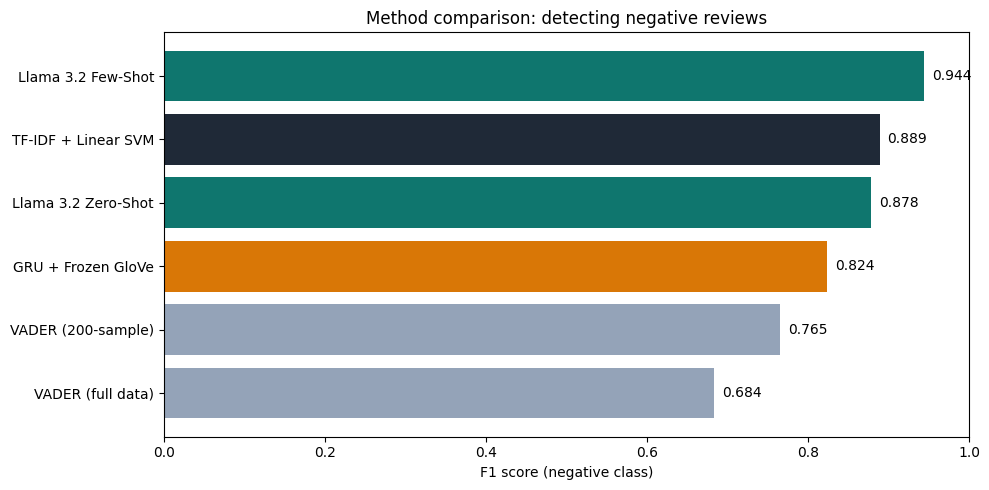

In [44]:
# ============================================================
# Code Cell 41: Visualize the comparison
# ============================================================

plt.figure(figsize=(10, 5))
colors = {"Lexicon": "#94A3B8", "LLM": "#0F766E",
          "Classical ML": "#1F2937", "Deep Learning": "#D97706"}
bar_colors = [colors[t] for t in comparison_df["Type"]]

plt.barh(comparison_df["Method"], comparison_df["Negative-class F1"], color=bar_colors)
plt.xlabel("F1 score (negative class)")
plt.title("Method comparison: detecting negative reviews")
plt.gca().invert_yaxis()
plt.xlim(0, 1.0)
for i, v in enumerate(comparison_df["Negative-class F1"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

### Comparison Findings

Reading the table above:

- **VADER is fast but weak on the negative class** — its lexicon misses polite or mixed-sentiment complaints, which is exactly where business value lies.
- **The TF-IDF + Linear SVM with `class_weight='balanced'` is the strongest classical baseline** and the most practical default — it's deterministic, fast, and the coefficients are directly interpretable.
- **The GRU adds little over SVM for this task**, which is consistent with the broader NLP literature: bag-of-words is hard to beat on short, polarized review text.
- **Llama 3.2 (especially few-shot) is the most contextually aware** and would be the right choice for a review-triage application where false negatives (missed complaints) are costly. The cost is wall-clock latency.

For a school owner, the practical answer is to use the SVM as the always-on classifier and reserve Llama for higher-stakes downstream extraction (what specifically did the reviewer dislike?).

## 14. Business Insights

The following insights are based on patterns observed in the review text and should be interpreted as directional indicators rather than complete drivers of enrollment decisions.

**Insight 1 — Coaching is the product, not the curriculum.**
Both LDA and BERTopic surface a dominant theme around instructors, coaching, and welcoming atmosphere. The SVM's top positive terms (great, love, helpful, amazing, welcoming) almost all describe people and experience. Marketing should lead with the coach.

**Insight 2 — Operational friction kills more memberships than bad classes do.**
The SVM's top negative terms (rude, told, cancel, money, business, contract, owner) are almost entirely about operations, not training. BERTopic's `topics_per_class` view confirms that 1-2-star reviews cluster on contract, billing, and front-desk themes. Audit and rewrite those workflows before adding new programs.

**Insight 3 — Use the right model for the right job.**
The SVM is an always-on classifier good enough to triage incoming reviews in real time (high accuracy, deterministic, fast). Llama 3.2 is the right tool for downstream extraction — once a review is flagged negative, ask the LLM what specifically the reviewer disliked, in their own words. This two-stage pipeline gives owners both detection and explanation.

## 15. Final Conclusion

This project used Yelp business and review data to analyze martial arts schools and identify patterns in customer feedback. The combination of EDA, sentiment analysis (VADER + Llama 3.2), topic modeling (LDA + BERTopic), and classification (TF-IDF + SVM, GRU + GloVe) gives a full picture of what customers describe in their reviews and how predictable that signal is from the text alone.

**Key results:**
- The SVM achieves strong classification performance (F1 on the negative class around 0.89), making it operationally usable for review triage.
- BERTopic's `topics_per_class` view is the most directly actionable artifact: it identifies which themes are over-represented in low-star reviews (the to-fix list) and which are over-represented in high-star reviews (the marketing copy).
- Llama 3.2 with few-shot prompting is the best-in-class for sentiment when latency is acceptable, especially for mixed-sentiment reviews where lexicon methods fail.

**Limitations:**
- Yelp reviews are voluntary feedback and self-select for engaged customers, so the findings are directional, not causal.
- The Llama evaluation uses a 200-review balanced sample to keep runtime tractable. Full-test-set evaluation would tighten the F1 estimate.
- Topics overlap because vocabulary overlaps; the BERTopic outliers (-1 cluster) absorb reviews that don't fit any theme.

**Next steps:**
- Apply the same pipeline to Google reviews (which have higher volume than Yelp for most martial arts schools).
- Extend the LLM prompt to extract aspect-level complaints (instructor, contract, facility) instead of binary sentiment.
- Build a small dashboard that auto-scores new reviews as they come in, flagging negatives within 24 hours.

## Appendix: Local Review Filtering Script Used Before Colab

This script was used locally to filter the large Yelp review JSON file into a smaller `reviews_filtered.csv` file. This was necessary because the original review file was too large to upload and process directly in Colab.

In [45]:
# Local script reference only. Do not run this cell in Colab unless
# the raw JSON file is available locally.

"""
import pandas as pd

business_df = pd.read_csv("business_filtered.csv")
martial_ids = set(business_df["business_id"])

output_file = "reviews_filtered.csv"
chunksize = 100000
filtered_chunks = []

for chunk in pd.read_json("yelp_academic_dataset_review.json",
                          lines=True, chunksize=chunksize):
    filtered = chunk[chunk["business_id"].isin(martial_ids)]
    filtered_chunks.append(filtered)

reviews = pd.concat(filtered_chunks)
reviews.to_csv(output_file, index=False)

print("Done. Filtered reviews:", len(reviews))
"""

'\nimport pandas as pd\n\nbusiness_df = pd.read_csv("business_filtered.csv")\nmartial_ids = set(business_df["business_id"])\n\noutput_file = "reviews_filtered.csv"\nchunksize = 100000\nfiltered_chunks = []\n\nfor chunk in pd.read_json("yelp_academic_dataset_review.json",\n                          lines=True, chunksize=chunksize):\n    filtered = chunk[chunk["business_id"].isin(martial_ids)]\n    filtered_chunks.append(filtered)\n\nreviews = pd.concat(filtered_chunks)\nreviews.to_csv(output_file, index=False)\n\nprint("Done. Filtered reviews:", len(reviews))\n'